# Train Sentinel-1 RoughNet on Planetary Computer RTC Data (Baseline Config)

Identical to `../04_train_s1_with_tessa_baseline.ipynb` in every respect (architecture, repeated-channel handling, zero-filled attrs, split, training loop, evaluation metrics) except `S1_DIR`, which points at `02_patch_extraction.ipynb`'s output (`s1_patches_tuk_pcrtc`, Planetary Computer RTC data) instead of the raw-SAFE-calibrated patches. Any metric difference from notebook 04's baseline is attributable specifically to the data source's calibration/terrain-correction quality, not a different experimental setup. It does not execute automatically.

## Important compatibility note

Tessa's model expects four conditioning channels per view (RGB/NIR) and eight metadata values per view. Sentinel-1 normally provides VV/VH, so this notebook uses a documented adapter: VV and VH are converted to dB, then the two channels are repeated to produce four channels. Sentinel-1 metadata is represented by zero-filled eight-value vectors unless acquisition metadata is available. This preserves Tessa's model interface, but it is an experimental baseline rather than a claim that SAR is equivalent to optical imagery.

The model and metric modules are imported from Tessa's repository. The checkpoint path is optional because a Tessa Sentinel-2 checkpoint is generally not weight-compatible with the Sentinel-1 input adapter. The architecture and metric definitions are the baseline; Sentinel-1 training starts from freshly initialized weights by default.

## GPU configuration

This notebook requires a CUDA-enabled PyTorch installation. It fails early if CUDA is unavailable, so an accidental CPU training run cannot consume the full dataset silently.

In [1]:
import os
import sys
import json
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import rasterio

assert torch.cuda.is_available(), 'CUDA is required. Run this notebook on the GPU environment.'
DEVICE = torch.device('cuda')
torch.backends.cudnn.benchmark = True
print('GPU:', torch.cuda.get_device_name(0))

GPU: NVIDIA GeForce RTX 4070 Ti SUPER


## Paths and training configuration

Edit these paths to the outputs of notebooks 02 and 03. The example points to the working data locations described in the project notes.

In [2]:
WORKING_REPO = Path('/cs/student/project_msc/2025/aibh/jiayiche')
TESSA_REPO = Path('/cs/student/project_msc/2025/aibh/jiayiche/tessa_baseline')
REGION = 'tuk'
LIDAR_DIR = WORKING_REPO / 'input_data' / 'lidar_patches_tuk_tessa'
S1_DIR = WORKING_REPO / 'input_data' / 's1_patches_tuk_pcrtc'
CHECKPOINT_DIR = WORKING_REPO / 'checkpoints'
OUTPUT_DIR = WORKING_REPO / 's1_training_outputs'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CONTEXT_K = 3
TARGET_HW = (256, 256)
BATCH_SIZE = 8
EPOCHS = 100
TIMESTEPS = 1000
LEARNING_RATE = 1e-4
VAL_FRACTION = 0.15
SEED = 42
NOISE_SCHEDULE = 'linear'
ATTENTION_VARIANT = 'default'

## Import Tessa's baseline implementation

The working tree intentionally does not contain Tessa's model and metrics modules, so imports use the cloned baseline path explicitly.

In [3]:
sys.path.insert(0, str(TESSA_REPO))
from src.model.unet import ConditionalUNet
from src.diffusion.scheduler import LinearDiffusionScheduler, CosineDiffusionScheduler
from src.diffusion.sampling import p_sample_loop_ddpm, p_sample_loop_ddim, p_sample_loop_plms
from src.utils.recon_metrics import rmse, bias, sigma_error, normal_angle_error, average_jsd_multiscale, log_psd_rmse, zncc

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

## Sentinel-1/LiDAR dataset adapter

The adapter matches patch IDs, loads LiDAR band 1 and mask band 2, removes the valid-pixel mean, converts positive VV/VH sigma-nought values to dB, upsamples the SAR window to 256 x 256, and repeats VV/VH to four channels for Tessa's U-Net. Invalid pixels are replaced before masking to prevent NaNs from propagating through training.

In [4]:
class LidarS1Dataset(Dataset):
    def __init__(self, s1_dir, lidar_dir, patch_ids, context_k=3, target_hw=(256, 256), train=False):
        self.s1_dir = Path(s1_dir)
        self.lidar_dir = Path(lidar_dir)
        self.patch_ids = list(patch_ids)
        self.context_k = context_k
        self.target_hw = target_hw
        self.train = train

    def __len__(self):
        return len(self.patch_ids)

    def __getitem__(self, index):
        patch_id = self.patch_ids[index]
        lidar_path = self.lidar_dir / f'lidar_patch_{patch_id}.tif'
        s1_path = self.s1_dir / f's1_patch_{patch_id}'
        with rasterio.open(lidar_path) as src:
            raw = src.read().astype(np.float32)
        target = raw[0]
        mask = (raw[1] > 0.5) if raw.shape[0] > 1 else np.isfinite(target)
        target = np.nan_to_num(target, nan=0.0, posinf=0.0, neginf=0.0)
        valid_count = max(1, int(mask.sum()))
        patch_mean = float(target[mask].sum() / valid_count)
        target = (target - patch_mean) * mask

        times = sorted(s1_path.glob('t*.tif'))[:self.context_k]
        if len(times) < self.context_k:
            raise RuntimeError(f'{s1_path} has fewer than {self.context_k} Sentinel-1 times')
        views = []
        for time_path in times:
            with rasterio.open(time_path) as src:
                sar = src.read()[:2].astype(np.float32)
            sar = np.nan_to_num(sar, nan=0.0, posinf=0.0, neginf=0.0)
            sar = np.maximum(sar, 1e-12)
            sar = 10.0 * np.log10(sar)
            sar_tensor = torch.from_numpy(sar).unsqueeze(0)
            sar_tensor = F.interpolate(sar_tensor, size=self.target_hw, mode='bilinear', align_corners=False).squeeze(0)
            sar_tensor = sar_tensor.repeat(2, 1, 1)
            views.append(sar_tensor)
        condition = torch.cat(views, dim=0)
        attrs = torch.zeros(8 * self.context_k, dtype=torch.float32)
        return {'lidar': torch.from_numpy(target).unsqueeze(0).float(), 'mask': torch.from_numpy(mask), 's1': condition.float(), 'attrs': attrs, 'patch_mean': torch.tensor(patch_mean), 'patch_id': patch_id}

## Pair patches and create a reproducible split

This is a within-region patch split. It is not a geographic holdout, so report it as an initial baseline rather than a final generalization estimate.

In [5]:
lidar_ids = {p.stem.split('_')[-1] for p in LIDAR_DIR.glob('lidar_patch_*.tif')}
s1_ids = {p.name.split('_')[-1] for p in S1_DIR.glob('s1_patch_*') if p.is_dir()}
paired_ids = sorted(lidar_ids & s1_ids)
assert paired_ids, 'No paired Sentinel-1/LiDAR patches found.'
random.Random(SEED).shuffle(paired_ids)
n_val = max(1, int(len(paired_ids) * VAL_FRACTION))
val_ids, train_ids = paired_ids[:n_val], paired_ids[n_val:]
print(f'Paired: {len(paired_ids)} | train: {len(train_ids)} | validation: {len(val_ids)}')
train_dataset = LidarS1Dataset(S1_DIR, LIDAR_DIR, train_ids, CONTEXT_K, TARGET_HW, train=True)
val_dataset = LidarS1Dataset(S1_DIR, LIDAR_DIR, val_ids, CONTEXT_K, TARGET_HW, train=False)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)


Paired: 1676 | train: 1425 | validation: 251


## Initialize Tessa's ConditionalUNet and scheduler

The Sentinel-1 adapter produces `4 * CONTEXT_K` conditioning channels and `8 * CONTEXT_K` metadata values, exactly matching the constructor contract used by Tessa's model.

In [6]:
model = ConditionalUNet(in_channels=1, cond_channels=4 * CONTEXT_K, attr_dim=8 * CONTEXT_K, base_channels=128, embed_dim=256, unet_depth=4, attention_variant=ATTENTION_VARIANT, cond_k=CONTEXT_K).to(DEVICE)
scheduler = (LinearDiffusionScheduler(TIMESTEPS, device=DEVICE) if NOISE_SCHEDULE == 'linear' else CosineDiffusionScheduler(TIMESTEPS, device=DEVICE))
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
print('Trainable parameters:', sum(p.numel() for p in model.parameters() if p.requires_grad))

Trainable parameters: 104625307


## Training loop

Tessa's objective is retained: sample a diffusion timestep, add forward noise to the demeaned LiDAR target, predict the clean target, and optimize masked MSE. Validation loss is calculated without parameter updates.

In [7]:
from torch.cuda.amp import autocast, GradScaler

def masked_mse(prediction, target, mask):
    valid = mask.bool().unsqueeze(1)
    error = (prediction - target) ** 2
    return error[valid].mean()

scaler = GradScaler()
history = {'train_loss': [], 'val_loss': []}
best_val = float('inf')
for epoch in range(EPOCHS):
    model.train()
    train_total = 0.0
    for batch in train_loader:
        target = batch['lidar'].to(DEVICE, non_blocking=True)
        condition = batch['s1'].to(DEVICE, non_blocking=True)
        attrs = batch['attrs'].to(DEVICE, non_blocking=True)
        mask = batch['mask'].to(DEVICE, non_blocking=True)
        timestep = torch.randint(0, TIMESTEPS, (target.size(0),), device=DEVICE)
        optimizer.zero_grad(set_to_none=True)
        with autocast():
            noisy = scheduler.q_sample(target, timestep)
            prediction = model(noisy, condition, attrs, timestep)
            loss = masked_mse(prediction, target, mask)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_total += loss.item()
    model.eval()
    val_total = 0.0
    with torch.no_grad():
        for batch in val_loader:
            target = batch['lidar'].to(DEVICE, non_blocking=True)
            condition = batch['s1'].to(DEVICE, non_blocking=True)
            attrs = batch['attrs'].to(DEVICE, non_blocking=True)
            mask = batch['mask'].to(DEVICE, non_blocking=True)
            timestep = torch.randint(0, TIMESTEPS, (target.size(0),), device=DEVICE)
            with autocast():
                prediction = model(scheduler.q_sample(target, timestep), condition, attrs, timestep)
                val_total += masked_mse(prediction, target, mask).item()
    train_loss = train_total / max(1, len(train_loader))
    val_loss = val_total / max(1, len(val_loader))
    history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
    print(f'Epoch {epoch + 1:03d}/{EPOCHS}: train={train_loss:.6f} val={val_loss:.6f}')
    if val_loss < best_val:
        best_val = val_loss
        torch.save({'model_state_dict': model.state_dict(), 'config': {'context_k': CONTEXT_K, 'timesteps': TIMESTEPS, 'noise_schedule': NOISE_SCHEDULE, 'region': REGION}, 'epoch': epoch + 1, 'val_loss': val_loss}, CHECKPOINT_DIR / f's1_{REGION}_pcrtc_unet_best.pth')


/tmp/ipykernel_336408/980383327.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_336408/980383327.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_336408/980383327.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 001/100: train=0.034899 val=0.017398
Epoch 002/100: train=0.015170 val=0.017695
Epoch 003/100: train=0.015311 val=0.016194
Epoch 004/100: train=0.014265 val=0.016824
Epoch 005/100: train=0.014080 val=0.017884
Epoch 006/100: train=0.014546 val=0.016921
Epoch 007/100: train=0.014230 val=0.016703
Epoch 008/100: train=0.014543 val=0.016541
Epoch 009/100: train=0.013771 val=0.015229
Epoch 010/100: train=0.014151 val=0.014876
Epoch 011/100: train=0.013719 val=0.015123
Epoch 012/100: train=0.013521 val=0.014593
Epoch 013/100: train=0.013625 val=0.014166
Epoch 014/100: train=0.014952 val=0.017544
Epoch 015/100: train=0.014820 val=0.014741
Epoch 016/100: train=0.014081 val=0.015931
Epoch 017/100: train=0.013724 val=0.018016
Epoch 018/100: train=0.014405 val=0.014590
Epoch 019/100: train=0.013614 val=0.015210
Epoch 020/100: train=0.013374 val=0.016093
Epoch 021/100: train=0.014073 val=0.014667
Epoch 022/100: train=0.013844 val=0.015526
Epoch 023/100: train=0.013089 val=0.016448
Epoch 024/1

## Evaluate with Tessa's reconstruction metrics

This uses DDIM by default for a deterministic comparison and reports the same physical/statistical metric family used by Tessa. The LiDAR mean is added back before metrics so RMSE and bias are in the original elevation units.

In [12]:
best_path = CHECKPOINT_DIR / f's1_{REGION}_pcrtc_unet_best.pth'
checkpoint = torch.load(best_path, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
sampler = p_sample_loop_ddim
metric_rows = []
example_patches = []  # keep a few full patches for the qualitative reconstruction grid
N_EXAMPLES = 6
with torch.no_grad():
    for batch in val_loader:
        target = batch['lidar'].to(DEVICE)
        condition = batch['s1'].to(DEVICE)
        attrs = batch['attrs'].to(DEVICE)
        mask = batch['mask'].to(DEVICE).bool()
        prediction = sampler(model, scheduler, target.shape, condition, attrs, DEVICE)
        means = batch['patch_mean'].to(DEVICE).view(-1, 1, 1, 1)
        gt_absolute = target + means
        pred_absolute = prediction + means
        for i, patch_id in enumerate(batch['patch_id']):
            gt_i, pred_i, mask_i = gt_absolute[i], pred_absolute[i], mask[i]
            gt_valid = gt_i.squeeze()[mask_i].cpu().numpy()
            pred_valid = pred_i.squeeze()[mask_i].cpu().numpy()
            row = {
                'patch_id': patch_id,
                'rmse_m': float(rmse(gt_i, pred_i, mask_i).item()),
                'bias_m': float(bias(gt_i, pred_i, mask_i).item()),
                'sigma_error_pct': float(sigma_error(gt_i, pred_i, mask_i).item()),
                'normal_angle_error_deg': float(normal_angle_error(gt_i, pred_i, mask_i, pixel_size=1.0, degrees=True).item()),
                'jsd': float(average_jsd_multiscale(gt_i, pred_i, pixel_size=1.0, mask=mask_i).item()),
                'psd_rmse': float(log_psd_rmse(gt_i, pred_i, pixel_size=1.0, mask=mask_i).item()),
                'zncc': float(zncc(gt_i, pred_i, mask_i).item()),
                'gt_std_val': float(gt_valid.std()) if gt_valid.size > 0 else float('nan'),
                'pred_std_val': float(pred_valid.std()) if pred_valid.size > 0 else float('nan'),
            }
            metric_rows.append(row)
            if len(example_patches) < N_EXAMPLES:
                example_patches.append({
                    'patch_id': patch_id,
                    'gt': gt_i.squeeze().cpu().numpy(),
                    'pred': pred_i.squeeze().cpu().numpy(),
                    'mask': mask_i.squeeze().cpu().numpy(),
                    's1_condition': condition[i].cpu().numpy(),  # shape (4*CONTEXT_K, H, W)
                })
metrics_path = OUTPUT_DIR / 's1_pcrtc_validation_metrics.json'
with metrics_path.open('w') as handle:
    json.dump(metric_rows, handle, indent=2)
print('Saved:', metrics_path)
print('Mean metrics:', {key: float(np.nanmean([row[key] for row in metric_rows])) for key in metric_rows[0] if key != 'patch_id'})


Saved: /cs/student/project_msc/2025/aibh/jiayiche/s1_training_outputs/s1_pcrtc_validation_metrics.json
Mean metrics: {'rmse_m': 0.17340003227095205, 'bias_m': -0.002000453434111007, 'sigma_error_pct': 33.24723197822552, 'normal_angle_error_deg': 1.784202730513189, 'jsd': 0.14511050529540534, 'psd_rmse': 1.8321885986632085, 'zncc': 0.2858124535300758, 'gt_std_val': 0.16917210750548964, 'pred_std_val': 0.11240974464917562}


In [11]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


Saved: /cs/student/project_msc/2025/aibh/jiayiche/s1_training_outputs/s1_gt_pred_std_scatter.png


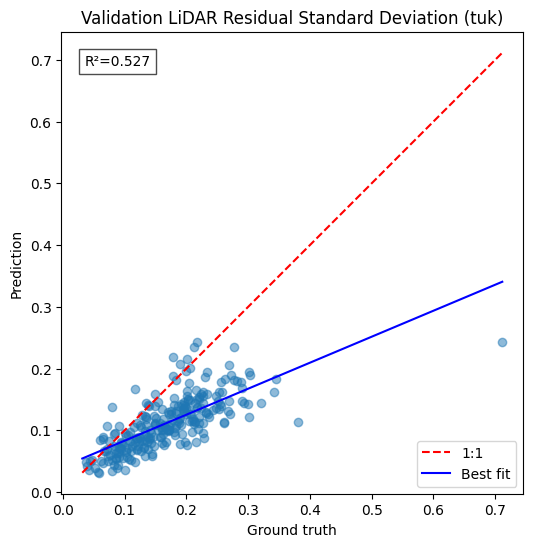

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df_val = pd.DataFrame(metric_rows)

x = df_val['gt_std_val']
y = df_val['pred_std_val']

plt.figure(figsize=(6, 6))
plt.scatter(x, y, alpha=0.5)

mn, mx = np.nanmin([x, y]), np.nanmax([x, y])
plt.plot([mn, mx], [mn, mx], 'r--', label='1:1')

mask = ~np.isnan(x) & ~np.isnan(y)
z = np.polyfit(x[mask], y[mask], 1)
p = np.poly1d(z)
xs = np.array([mn, mx])
plt.plot(xs, p(xs), 'b-', label='Best fit')

r2 = np.corrcoef(x[mask], y[mask])[0, 1] ** 2
plt.text(0.05, 0.95, f'R²={r2:.3f}', transform=plt.gca().transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))

plt.xlabel('Ground truth')
plt.ylabel('Prediction')
plt.title(f'Validation LiDAR Residual Standard Deviation ({REGION})')
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.savefig(OUTPUT_DIR / 's1_gt_pred_std_scatter.png', dpi=150, bbox_inches='tight')
print('Saved:', OUTPUT_DIR / 's1_gt_pred_std_scatter.png')
plt.show()


Saved: /cs/student/project_msc/2025/aibh/jiayiche/s1_training_outputs/s1_patch_reconstructions_pdfs.png


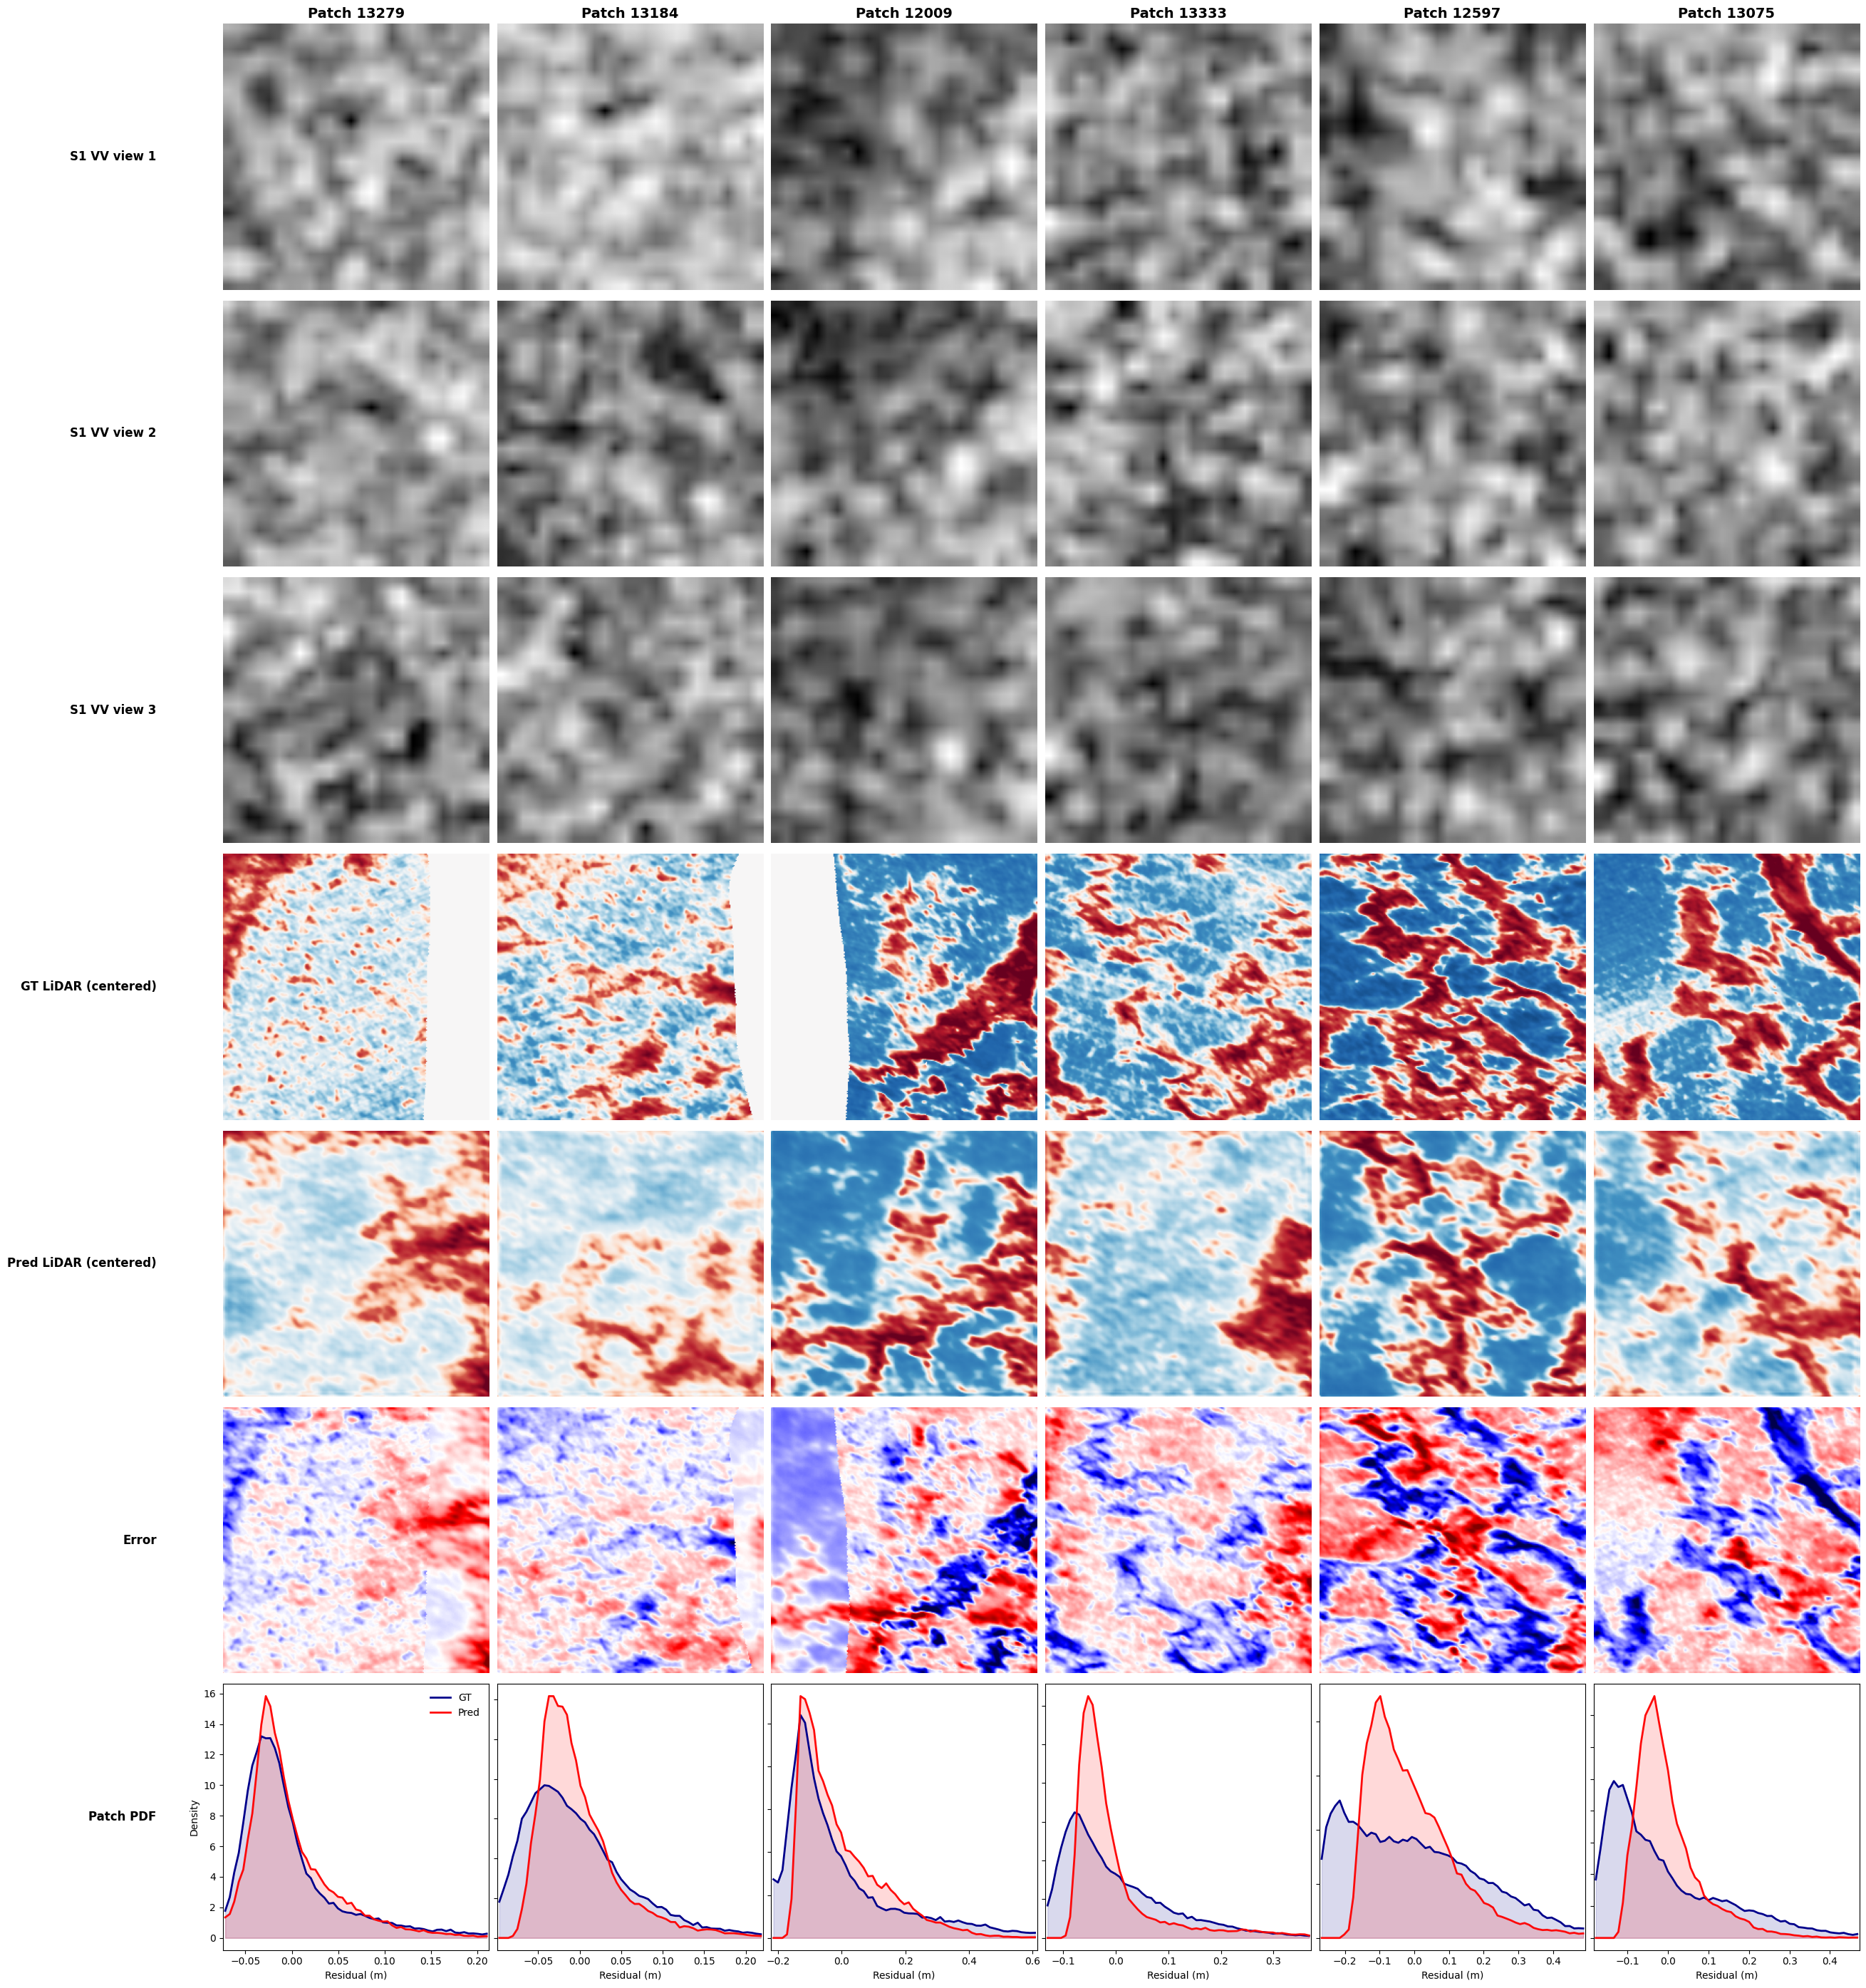

In [14]:
from matplotlib.colors import SymLogNorm

n_show = min(6, len(example_patches))
num_context_rows = CONTEXT_K
num_data_rows = 4
total_rows = num_context_rows + num_data_rows
num_cols = n_show

centered_gt = []
centered_pred = []
for p in example_patches[:n_show]:
    gt_mean = p['gt'][p['mask']].mean()
    pred_mean = p['pred'][p['mask']].mean()
    centered_gt.append(p['gt'] - gt_mean)
    centered_pred.append(p['pred'] - pred_mean)

all_gt = np.stack(centered_gt)
all_pred = np.stack(centered_pred)
max_abs_resid = np.quantile(np.abs(np.concatenate([all_gt.ravel(), all_pred.ravel()])), 0.995)
signed_error = all_pred - all_gt
max_abs_error = np.quantile(np.abs(signed_error.ravel()), 0.995)
norm = SymLogNorm(linthresh=0.1, linscale=1.0, vmin=-max_abs_resid, vmax=max_abs_resid, base=10)

row_titles = [f'S1 VV view {k + 1}' for k in range(CONTEXT_K)] + ['GT LiDAR (centered)', 'Pred LiDAR (centered)', 'Error', 'Patch PDF']

tile_size_inches = 4.0
fig, axes = plt.subplots(total_rows, num_cols, figsize=(num_cols * tile_size_inches + 2, total_rows * tile_size_inches), squeeze=False)

for col in range(num_cols):
    p = example_patches[col]
    gt_i, pred_i, mask_i = centered_gt[col], centered_pred[col], p['mask']
    s1_cond = p['s1_condition']

    axes[0, col].set_title(f"Patch {p['patch_id']}", fontsize=14, fontweight='bold')

    for k in range(CONTEXT_K):
        ax = axes[k, col]
        ax.imshow(s1_cond[k * 4], cmap='gray')
        ax.axis('off')

    row_gt = num_context_rows
    ax = axes[row_gt, col]
    im_gt = ax.imshow(gt_i, cmap='RdBu_r', norm=norm)
    ax.axis('off')

    row_pred = num_context_rows + 1
    ax = axes[row_pred, col]
    im_pred = ax.imshow(pred_i, cmap='RdBu_r', norm=norm)
    ax.axis('off')

    row_err = num_context_rows + 2
    err_i = pred_i - gt_i
    ax = axes[row_err, col]
    im_err = ax.imshow(err_i, cmap='seismic', vmin=-max_abs_error, vmax=max_abs_error)
    ax.axis('off')

    row_pdf = num_context_rows + 3
    ax = axes[row_pdf, col]
    gt_vals = gt_i[mask_i]
    pred_vals = pred_i[mask_i]
    if gt_vals.size > 1 and pred_vals.size > 1:
        all_vals = np.concatenate([gt_vals, pred_vals])
        vmin_pdf, vmax_pdf = np.quantile(all_vals, [0.01, 0.99])
        if np.isclose(vmin_pdf, vmax_pdf):
            vmin_pdf, vmax_pdf = all_vals.min(), all_vals.max()
        bins = np.linspace(vmin_pdf, vmax_pdf, 60)
        gt_pdf, edges = np.histogram(gt_vals, bins=bins, density=True)
        pred_pdf, _ = np.histogram(pred_vals, bins=bins, density=True)
        centers = 0.5 * (edges[:-1] + edges[1:])
        ax.plot(centers, gt_pdf, color='darkblue', lw=2, label='GT')
        ax.plot(centers, pred_pdf, color='red', lw=2, alpha=0.95, label='Pred')
        ax.fill_between(centers, gt_pdf, color='darkblue', alpha=0.15)
        ax.fill_between(centers, pred_pdf, color='red', alpha=0.15)
        ax.set_xlim(vmin_pdf, vmax_pdf)
    ax.set_xlabel('Residual (m)', fontsize=10)
    if col == 0:
        ax.set_ylabel('Density', fontsize=10)
        ax.legend(fontsize=10, frameon=False)
    else:
        ax.set_yticklabels([])
    ax.set_box_aspect(1)

for row in range(total_rows):
    axes[row, 0].text(-0.25, 0.5, row_titles[row], ha='right', va='center', transform=axes[row, 0].transAxes, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 's1_patch_reconstructions_pdfs.png', dpi=200, bbox_inches='tight')
print('Saved:', OUTPUT_DIR / 's1_patch_reconstructions_pdfs.png')
plt.show()


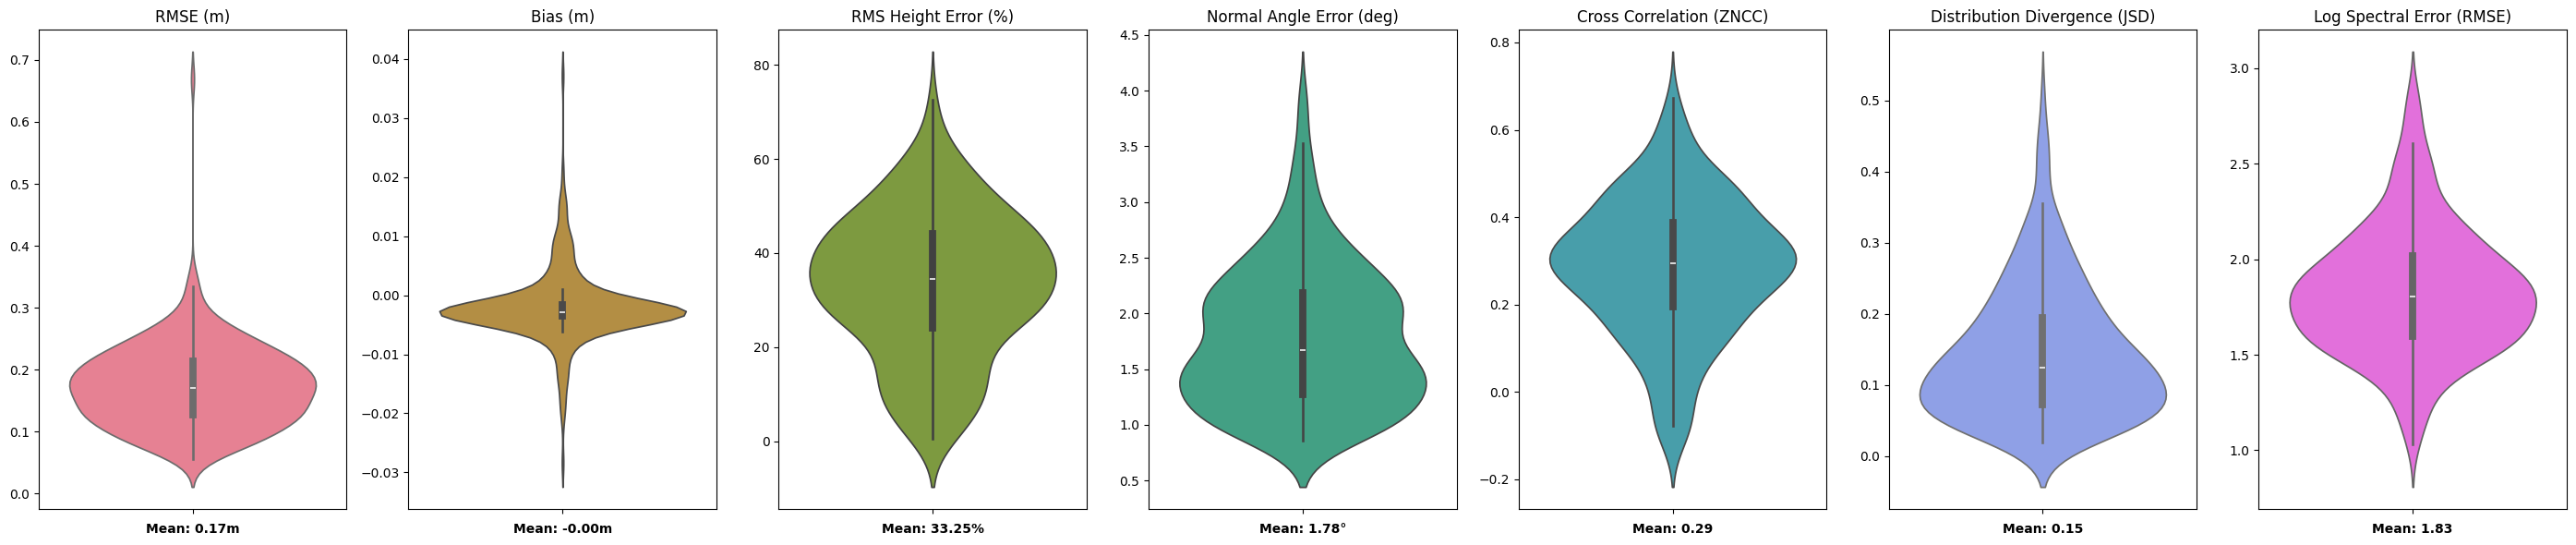

Saved: /cs/student/project_msc/2025/aibh/jiayiche/s1_training_outputs/s1_pcrtc_metric_violin_plots.png


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'df_val' not in dir():
    df_val = pd.DataFrame(metric_rows)

metrics_to_plot = [
    ('rmse_m', 'RMSE (m)', 'm'),
    ('bias_m', 'Bias (m)', 'm'),
    ('sigma_error_pct', 'RMS Height Error (%)', '%'),
    ('normal_angle_error_deg', 'Normal Angle Error (deg)', '°'),
    ('zncc', 'Cross Correlation (ZNCC)', ''),
    ('jsd', 'Distribution Divergence (JSD)', ''),
    ('psd_rmse', 'Log Spectral Error (RMSE)', ''),
]

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(4 * len(metrics_to_plot), 6))
colors = sns.color_palette('husl', len(metrics_to_plot))

for ax, (key, title, unit), color in zip(axes, metrics_to_plot, colors):
    values = df_val[key].dropna()
    sns.violinplot(y=values, ax=ax, color=color, inner='box')
    ax.set_title(title)
    ax.set_ylabel('')
    mean_val = values.mean()
    ax.set_xlabel(f'Mean: {mean_val:.2f}{unit}', fontsize=10, fontweight='bold')

plt.tight_layout()
out_path = OUTPUT_DIR / 's1_pcrtc_metric_violin_plots.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', out_path)


## Qualitative success/failure case analysis

Inspired by qualitative discussion in Tessa's dissertation (which describes,
in text, that the model captures large ridges/crevasses well but defaults to
repetitive patterns on monotonous ice textures) -- this makes that comparison
visual and concrete rather than a written observation.

For each example patch, splits the image into blocks and finds two textured
regions (above-median ground-truth roughness, so flat background areas don't
count): the block with the **lowest** reconstruction error (a genuine
success -- real roughness, correctly captured) and the block with the
**highest** reconstruction error (a genuine failure -- real roughness, missed
or smoothed over). Circles mark both directly on the GT LiDAR image.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def find_success_failure_regions(gt, pred, mask, block_size=64):
    """Split the patch into blocks; success = textured block with lowest error,
    failure = textured block with highest error. 'Textured' excludes flat/boring
    background blocks so the comparison is about real roughness, not empty ice."""
    error = np.abs(pred - gt)
    h, w = gt.shape
    block_stats = []
    for i in range(h // block_size):
        for j in range(w // block_size):
            r0, r1 = i * block_size, (i + 1) * block_size
            c0, c1 = j * block_size, (j + 1) * block_size
            block_mask = mask[r0:r1, c0:c1]
            if block_mask.sum() < 0.5 * block_mask.size:
                continue  # skip mostly-invalid blocks
            block_stats.append({
                'row': r0 + block_size // 2, 'col': c0 + block_size // 2,
                'gt_std': gt[r0:r1, c0:c1][block_mask].std(),
                'error': error[r0:r1, c0:c1][block_mask].mean(),
            })
    if not block_stats:
        return None, None
    median_std = np.median([b['gt_std'] for b in block_stats])
    textured = [b for b in block_stats if b['gt_std'] >= median_std] or block_stats
    success = min(textured, key=lambda b: b['error'])
    failure = max(textured, key=lambda b: b['error'])
    return success, failure


n_show = min(6, len(example_patches))
fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 4.5))
if n_show == 1:
    axes = [axes]

for ax, patch in zip(axes, example_patches[:n_show]):
    gt, pred, mask = patch['gt'], patch['pred'], patch['mask']
    gt_display = gt - gt[mask].mean()  # recenter for display only, avoids the saturated-color bug from before

    ax.imshow(gt_display, cmap='terrain')
    ax.set_title(f"Patch {patch['patch_id']}")
    ax.axis('off')

    success, failure = find_success_failure_regions(gt, pred, mask)
    if success is not None:
        ax.add_patch(plt.Circle((success['col'], success['row']), 20, edgecolor='lime', facecolor='none', linewidth=2.5))
        ax.annotate('Success', (success['col'], success['row']), color='lime', fontsize=8, fontweight='bold',
                    xytext=(success['col'], success['row'] - 35), ha='center')
    if failure is not None:
        ax.add_patch(plt.Circle((failure['col'], failure['row']), 20, edgecolor='red', facecolor='none', linewidth=2.5))
        ax.annotate('Failure', (failure['col'], failure['row']), color='red', fontsize=8, fontweight='bold',
                    xytext=(failure['col'], failure['row'] + 45), ha='center')

plt.tight_layout()
out_path = OUTPUT_DIR / 's1_success_failure_annotated.png'  # rename per-notebook if you want, e.g. 's1_pcrtc_...'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', out_path)


## Comparison protocol

Compare this JSON with Tessa's Sentinel-2 validation summary using the same patch split policy, sampler, LiDAR units, mask definition, and metric settings. Do not compare a within-Tuk random split directly with Tessa's cross-region validation numbers without labeling the difference in experimental design.